# Interaction Store

Persistent INDRA-based curation of gene interactions for exploratory mechanistic research.

In [3]:
import json
import pathlib
from datetime import date
from functools import partial
import graph_tool.all as gt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
from indra.statements import (
    Agent, Evidence,
    Activation, Inhibition, Phosphorylation,
    Complex, Conversion, DecreaseAmount, IncreaseAmount,
    stmts_to_json, stmts_from_json,
)
from gene_registry import (
    gene_info, 
    all_groups, 
    all_contexts,                
    genes_by_context, 
    genes_by_group, 
    interactors,
    query_statements, 
    query_genes,
    load_registry, 
    save_registry,
    add_gene, 
    update_gene, 
    add_to_group, 
    add_reference,
    group_members, 
    get_by_chromosome, 
    rescue_candidates,
    enrich_graph, 
)    
from indra_cache import get_statements_batch, cache_summary
from utils import (
    load_store, 
    save_store,
    add_statements, 
    ev, 
    ag, 
    summarize,
    neighbors,
    path_between,
    stmts_for,
    circos_plot,
    register_shifted_cmap,
)
from visualization import interactive_network, save_static_png
from geneinfo.genelist import GeneList as glist
from vscodenb import set_vscode_theme
set_vscode_theme()
statements_path = pathlib.Path('statements.json')
genes_path = pathlib.Path('genes.json')

## Add new statements

Use this cell as a template as the network grows.

In [4]:
new = [
    # Example — replace with real interactions:
    # Activation(
    #     ag('GENE_A'), ag('GENE_B'),
    #     evidence=[ev('mechanism text here', context='module name')]
    # ),
]

if new:
    add_statements(new)
    summarize()
else:
    print('No new statements to add.')

No new statements to add.


## Enrich from INDRA DB

Query the public INDRA database for literature-supported statements
connecting your gene list. Requires internet access.

In [5]:

GENE_LIST = [
    # Autosomal
    'ADRA2C', 'IRS2', 'TPTE', 'XRN2', 'RBMX2', 'SORCS3', 'SPATC1', 'HIVEP3',
    # X-linked
    'PRKX', 'HDAC6', 'RBMX', 'MAP7D3', 'DYNLT3', 'UPF3B', 'DDX3X',
    'PJA1', 'AKAP4', 'BEX2', 'OCRL', 'OFD1', 'EDA',
    # Y-linked
    'PRKY',
]

print(f'Querying INDRA DB for {len(GENE_LIST)} genes (cached results are instant) ...\n')
all_stmts = get_statements_batch(GENE_LIST, ev_limit=5)

print(f'\n{cache_summary()}')

Querying INDRA DB for 22 genes (cached results are instant) ...

  ADRA2C: 881 statements (cached)
  IRS2: 3409 statements (cached)
  TPTE: 225 statements (cached)
  XRN2: 1012 statements (cached)
  RBMX2: 188 statements (cached)
  SORCS3: 107 statements (cached)
  SPATC1: 37 statements (cached)
  HIVEP3: 542 statements (cached)
  PRKX: 546 statements (cached)
  HDAC6: 9293 statements (cached)
  RBMX: 1052 statements (cached)
  MAP7D3: 395 statements (cached)
  DYNLT3: 218 statements (cached)
  UPF3B: 512 statements (cached)
  DDX3X: 3372 statements (cached)
  PJA1: 459 statements (cached)
  AKAP4: 2922 statements (cached)
  BEX2: 422 statements (cached)
  OCRL: 726 statements (cached)
  OFD1: 835 statements (cached)
  EDA: 2378 statements (cached)
  PRKY: 166 statements (cached)

Total: 29697 statements (22 cached)

INDRA DB cache: 27 genes

  ADRA2C          881 stmts  fetched 2026-03-12  (2d ago)
  AKAP4          2922 stmts  fetched 2026-03-12  (2d ago)
  AKT1          20527 stmts  

In [25]:
from pprint import pprint
pprint(genes_path.read_text())

('{\n'
 '  "ADCY": {\n'
 '    "chromosome": "auto",\n'
 '    "groups": [\n'
 '      "cAMP/PKA module"\n'
 '    ],\n'
 '    "notes": "Adenylyl cyclase; converts ATP to cAMP. Target of Gi-coupled '
 'ADRA2C suppression."\n'
 '  },\n'
 '  "ADGRG4": {\n'
 '    "analysis_origin": {\n'
 '      "analysis": "Siepel_ARGweaver-D_2020",\n'
 '      "note": "Human admixture into Neanderthals",\n'
 '      "source": "literature"\n'
 '    },\n'
 '    "chromosome": "X",\n'
 '    "coordinates": {\n'
 '      "hg38": {\n'
 '        "chrom": "chrX",\n'
 '        "end": 136416890,\n'
 '        "start": 136300962\n'
 '      }\n'
 '    },\n'
 '    "groups": [\n'
 '      "Siepel_ARGweaver-D_2020"\n'
 '    ],\n'
 '    "references": [\n'
 '      {\n'
 '        "doi": "10.1371/journal.pgen.1008895",\n'
 '        "note": "X-linked region with evidence of human-to-Neanderthal gene '
 'flow"\n'
 '      }\n'
 '    ]\n'
 '  },\n'
 '  "ADRA2C": {\n'
 '    "analysis_origin": {\n'
 '      "analysis": "Tishkoff_IBDmix_202

In [22]:
# gene_info, all_groups, all_contexts,
# genes_by_context, genes_by_group, interactors,

gene_info('DYNLT3')

In [17]:
list(all_groups())

[]

In [18]:
genes_by_group('Siepel_ARGweaver-D_2020')

< Empty GeneList>

In [ ]:
list(all_contexts())

In [19]:
genes_by_context('Dynein motor complex assembly')

DYNC1H1,DYNC1I2,DYNC1LI1,DYNLT3


In [31]:
query_genes(groups=r'.*')

{}

In [26]:
query_genes(gene=r'MAP.*', analysis=r'Sie.*')

{}

In [ ]:
#query_genes(gene=, group=, chromosome=, rescue_only=, analysis=)

In [21]:
query_statements(gene=r'DYN.*',
# stmt_type=, context=,
#  hypothesis_only=False
 )

[]

```python
from gene_registry import load_registry, save_registry                                      

# Registry                                                                                            
reg = load_registry()                                                                       
reg['MAPT']['notes'] = 'Updated note'
del reg['SOME_GENE']  # remove an entry
save_registry(reg)

# Statements:
stmts = load_store()        # returns INDRA Statement objects
for s in stmts:
    # modify evidence, agents, etc.
    s.evidence[0].annotations['context'] = 'new context'
stmts = [s for s in stmts if s.subj.name != 'REMOVE_ME']  # filter
save_store(stmts)
```

## Build graph

In [6]:
stmts = load_store(statements_path)
reg = json.loads(genes_path.read_text()) if genes_path.exists() else {}

G = gt.Graph(directed=True)
G.vp['name']       = G.new_vertex_property('string')
G.vp['chromosome']  = G.new_vertex_property('string')
G.ep['stmt_type']   = G.new_edge_property('string')

node_idx: dict[str, int] = {}

def _get_or_add(name: str):
    if name not in node_idx:
        v = G.add_vertex()
        node_idx[name] = int(v)
        G.vp['name'][v] = name
        info = reg.get(name, {})
        G.vp['chromosome'][v] = info.get('chromosome', 'unknown')
    return G.vertex(node_idx[name])

for s in stmts:
    agents = [a for a in s.agent_list() if a is not None]
    stype = type(s).__name__
    if stype == 'Complex':
        for i, a in enumerate(agents):
            for b in agents[i+1:]:
                va, vb = _get_or_add(a.name), _get_or_add(b.name)
                e = G.add_edge(va, vb)
                G.ep['stmt_type'][e] = 'Complex'
    elif len(agents) >= 2:
        va = _get_or_add(agents[0].name)
        vb = _get_or_add(agents[-1].name)
        e = G.add_edge(va, vb)
        G.ep['stmt_type'][e] = stype

print(f'Graph: {G.num_vertices()} nodes, {G.num_edges()} edges')

Graph: 31 nodes, 25 edges


In [ ]:

path_between('ADRA2C', 'MAPT', G)

ADRA2C → ADCY → cAMP → PKA → MAPT


In [ ]:
interactors('ADRA2C')

## Visualise

In [7]:
stmts = load_store(statements_path)
reg = json.loads(genes_path.read_text())

display(interactive_network(stmts, reg,
    # node_size=100,
    # text_color="black",
    # font_weight='bold',
    # text_outline=False,
    # border_width=7,
    # edge_width=5,
#    background_color='#1F1F1F',
    # font_size='20px',
    chrom_colors={'auto': "#56A51E", 'X': "#D72E2E", "Y": "#1768C6"},
))
save_static_png(stmts, reg)

Static PNG → interaction_network.png


'interaction_network.png'

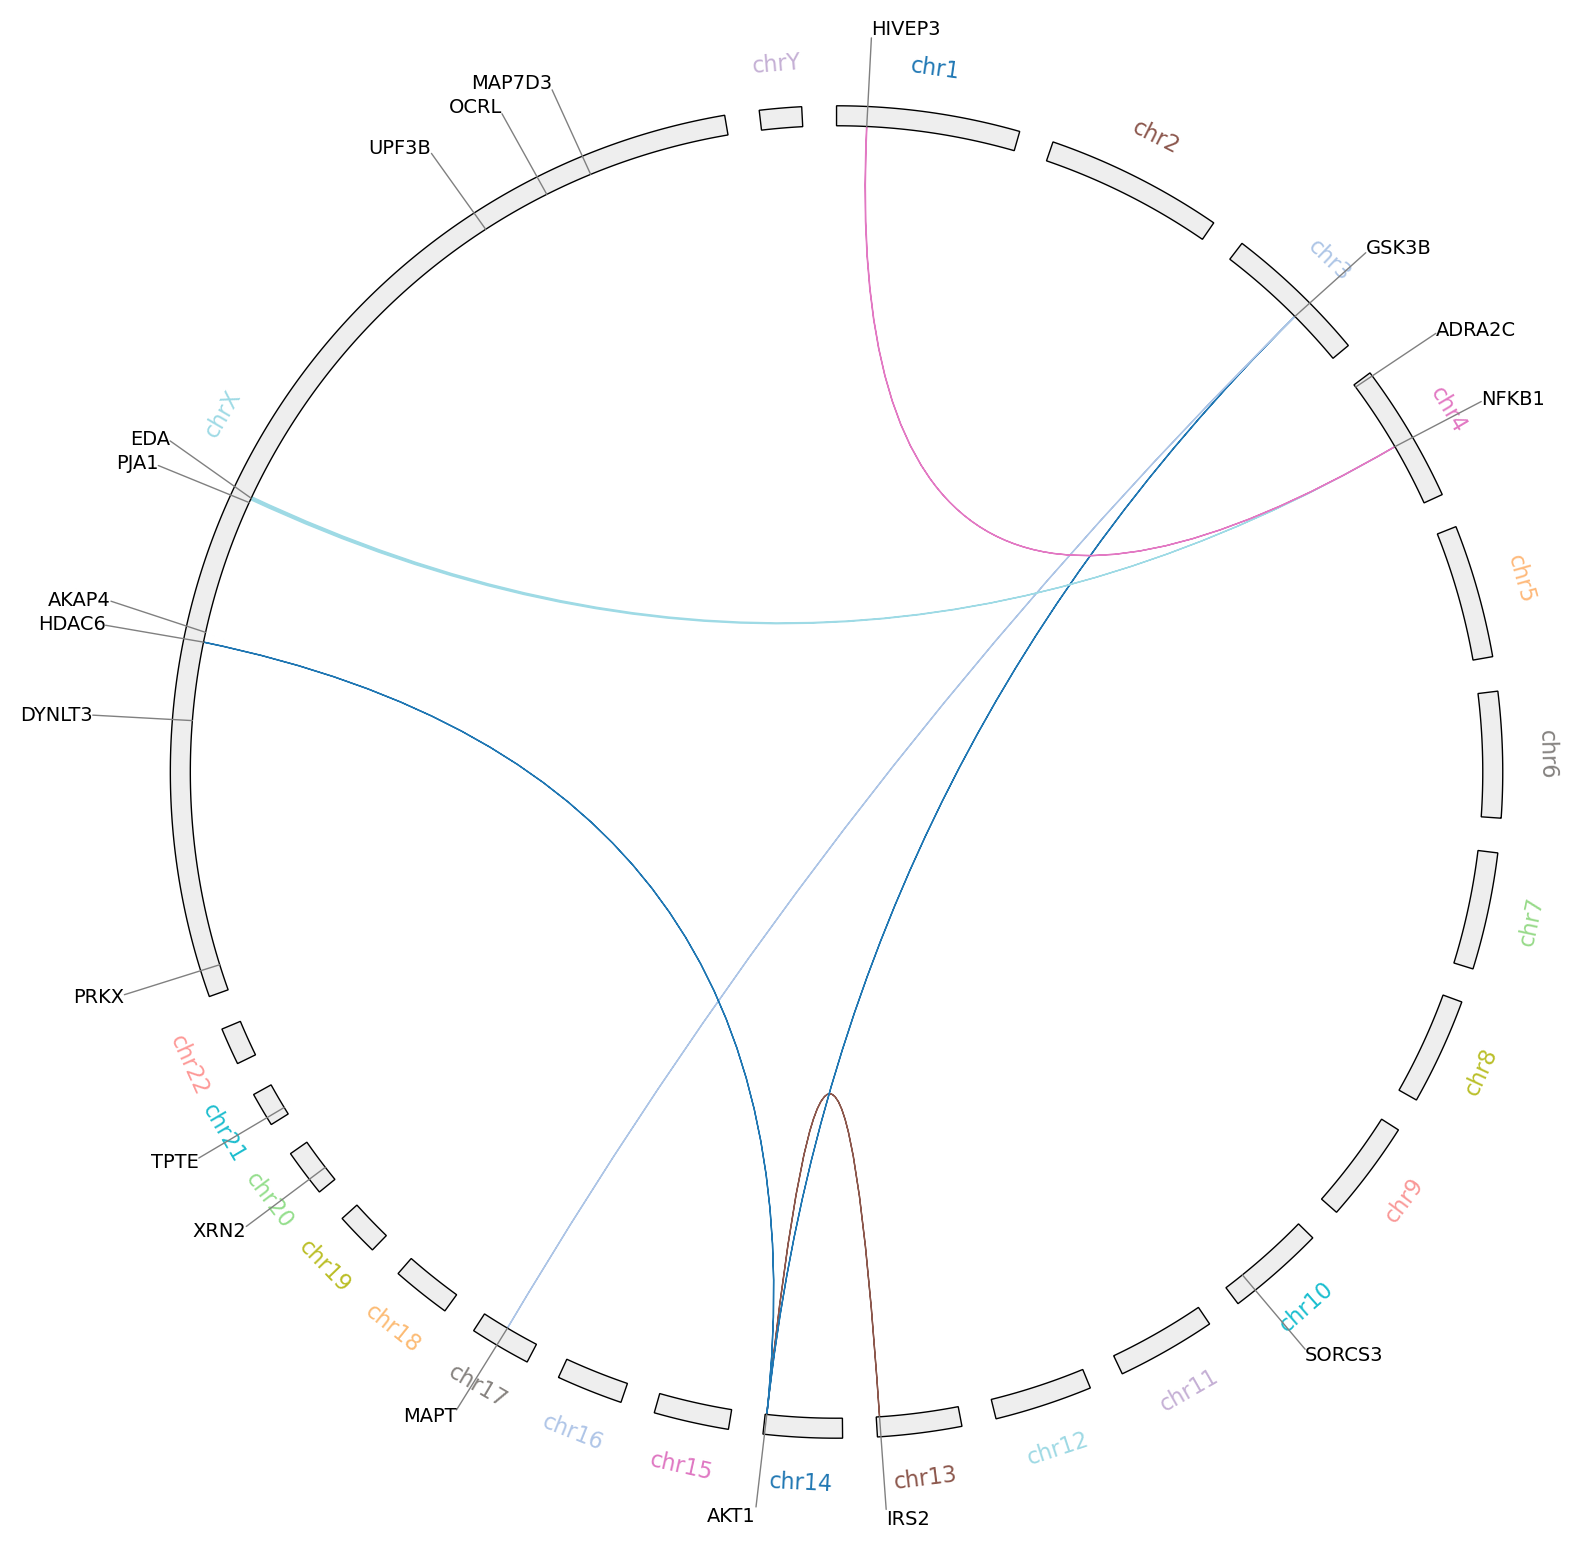

In [ ]:
stmts = load_store(statements_path)
reg = json.loads(genes_path.read_text()) if genes_path.exists() else {}

cmap = register_shifted_cmap('tab20')
# cmap = 'tab10'

circos_plot(stmts, reg, cmap=cmap, scalings=dict(chrX=10))